In [47]:
import os

count = 0

for root, dirs, files in os.walk("/content/extracted2_folder"):
    count += len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print("Total images:", count)

Total images: 7200


In [3]:
!pip install split-folders
import os
import random
import shutil
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import splitfolders

from IPython.display import display
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.densenet import (DenseNet121,
                                                    preprocess_input)
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.layers import (BatchNormalization, Dense,
                                     Dropout, Flatten, Input)
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
SEED = 123

### Fuse the Training/Testing folders 

In [ ]:
RAW_PATH = '../content/extracted_folder/brain_tumor_mri'  
DATASET_PATH = '../content/brain_tumor_mri_dataset'   

if not os.path.exists(DATASET_PATH):
    classes_brutes = os.listdir(os.path.join(RAW_PATH, 'Training'))
    for classe in classes_brutes:
        os.makedirs(os.path.join(DATASET_PATH, classe), exist_ok=True)
        for sous_dossier in ['Training', 'Testing']:
            source = os.path.join(RAW_PATH, sous_dossier, classe)
            for nom_fichier in os.listdir(source):
                shutil.copy(
                    os.path.join(source, nom_fichier),
                    os.path.join(DATASET_PATH, classe, f'{sous_dossier}_{nom_fichier}'))
    print('Fusion terminée.')
else:
    print('Dossier déjà fusionné, rien à faire.')

Fusion terminée.


### Explore the brain tumor MRI dataset

In [7]:
dir_list = os.listdir(DATASET_PATH)
print(dir_list)

['glioma', 'notumor', 'pituitary', 'meningioma']


In [8]:
num_of_images = []
for root, dirs, files in os.walk(DATASET_PATH):
    if root == DATASET_PATH: continue
    print('{}: {}'.format(os.path.basename(root), len(files)))
    num_of_images.append(len(files))

glioma: 1800
notumor: 1800
pituitary: 1800
meningioma: 1800


path: ../data_sources/brain_tumor_mri_dataset/glioma/Training_Tr-gl_113.jpg
size: (512, 512)
mode: L
format: JPEG


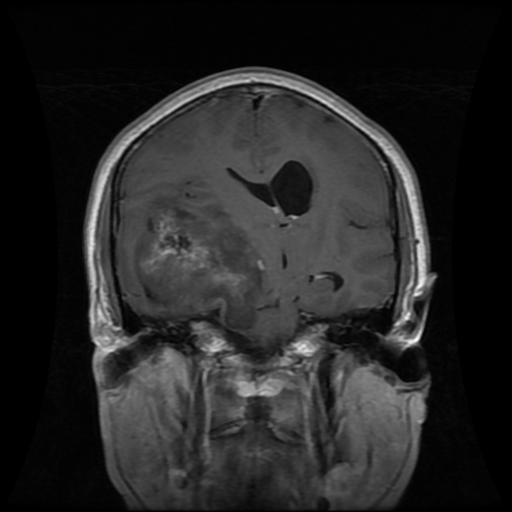

In [9]:
SEED = 123
random.seed(SEED)
rand_img = Image.open(random.choice(glob(DATASET_PATH + '/**/*')))

print('path:', rand_img.filename)
print('size:', rand_img.size)
print('mode:', rand_img.mode)
print('format:', rand_img.format)
display(rand_img)

### Visualize the brain tumor MRI dataset

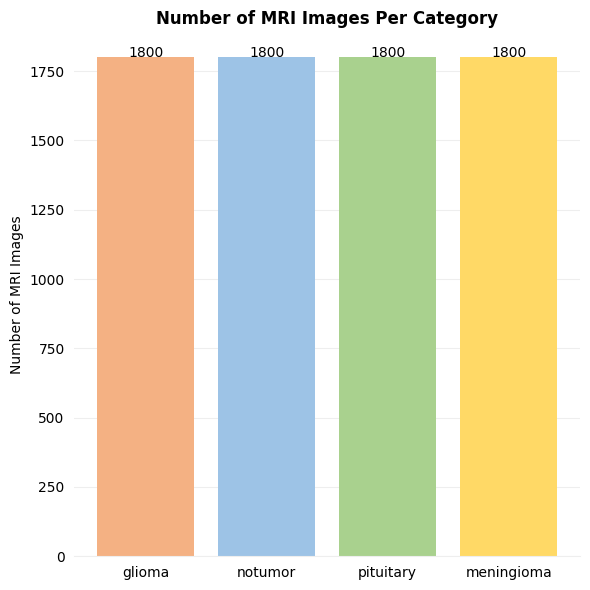

In [11]:
x_coord = np.arange(len(dir_list))
colors = ['#f4b183', '#9dc3e6', '#a9d18e', '#ffd966']

fig, ax = plt.subplots(facecolor='white', figsize=(6,6))
ax.bar(x_coord, num_of_images, color=colors)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#EEEEEE')

ax.yaxis.grid(True, color='#EEEEEE')
ax.set_axisbelow(True)

plt.xticks(x_coord, dir_list)
ax.tick_params(bottom=False, left=False)

plt.title('Number of MRI Images Per Category', fontweight='bold')
plt.ylabel('Number of MRI Images')

for i in range(len(x_coord)):
    plt.text(i, num_of_images[i], num_of_images[i], ha='center')

plt.tight_layout()
if not os.path.exists('figures'):
    os.makedirs('figures')
plt.savefig('figures/bar_chart_cerveau.png', dpi=200)
plt.show()

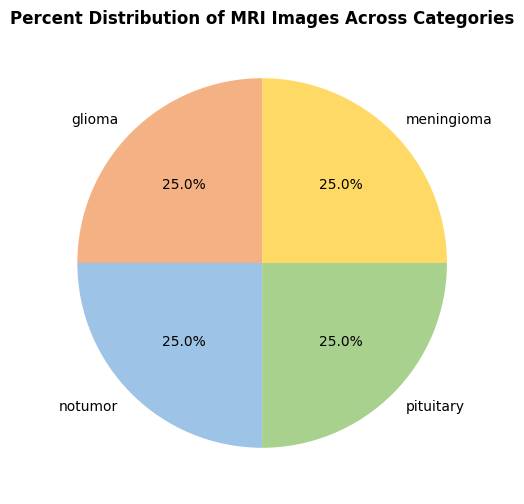

In [12]:
plt.figure(facecolor='white', figsize=(6,6))
plt.pie(num_of_images,
        labels=dir_list,
        colors=colors,
        autopct='%.1f%%',
        startangle=90)
plt.title('Percent Distribution of MRI Images Across Categories', fontweight='bold')
plt.savefig('figures/pie_chart_cerveau.png', dpi=200)
plt.show()

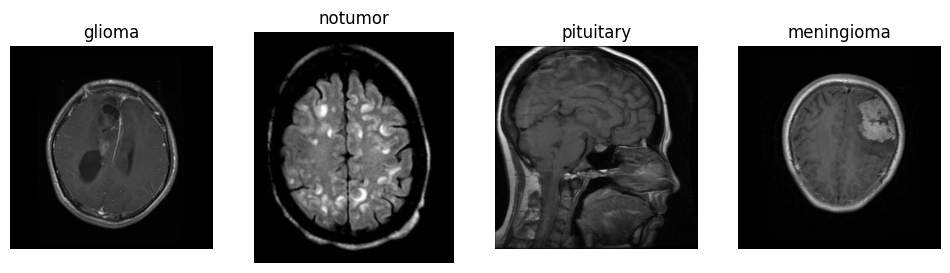

In [13]:
plt.figure(facecolor='white', figsize=(12,3))
for i in range(4):
    ax = plt.subplot(1, 4, i + 1)
    path = random.choice(glob(DATASET_PATH + '/' + dir_list[i] + '/*'))
    plt.imshow(Image.open(path), cmap='gray')
    plt.title(dir_list[i])
    plt.axis('off')
plt.savefig('figures/random_images_cerveau.png', dpi=200)
plt.show()

### Preprocess the brain tumor MRI dataset

In [15]:
OUTPUT_PATH = '../content/dataset_subsets_cerveau'
if not os.path.exists(OUTPUT_PATH):
    splitfolders.ratio(DATASET_PATH, OUTPUT_PATH, SEED, (.7, .1, .2))

Copying files: 7200 files [00:02, 2670.63 files/s]


In [49]:
import os
import hashlib
TRAIN_DIR = "/content/data/train"
VAL_DIR   = "/content/data/val"
TEST_DIR  = "/content/data/test"

def md5(file_path):
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

def get_hashes(folder):
    hashes = {}
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                path = os.path.join(root, file)
                hashes[md5(path)] = path
    return hashes

print("Calcul des empreintes...")

train_hashes = get_hashes(TRAIN_DIR)
val_hashes   = get_hashes(VAL_DIR)
test_hashes  = get_hashes(TEST_DIR)

train_val = set(train_hashes.keys()) & set(val_hashes.keys())
train_test = set(train_hashes.keys()) & set(test_hashes.keys())
val_test = set(val_hashes.keys()) & set(test_hashes.keys())

print("\n===== Vérification des doublons =====")

print(f"Train ↔ Validation : {len(train_val)} doublon(s)")
for h in list(train_val)[:5]:
    print(train_hashes[h])
    print(val_hashes[h])
    print()

print(f"Train ↔ Test : {len(train_test)} doublon(s)")
for h in list(train_test)[:5]:
    print(train_hashes[h])
    print(test_hashes[h])
    print()

print(f"Validation ↔ Test : {len(val_test)} doublon(s)")
for h in list(val_test)[:5]:
    print(val_hashes[h])
    print(test_hashes[h])
    print()

if len(train_val) == 0 and len(train_test) == 0 and len(val_test) == 0:
    print("\n Aucun data leakage détecté.")
else:
    print("\n Des images identiques sont présentes dans plusieurs ensembles.")

Calcul des empreintes...

===== Vérification des doublons =====
Train ↔ Validation : 0 doublon(s)
Train ↔ Test : 0 doublon(s)
Validation ↔ Test : 0 doublon(s)

 Aucun data leakage détecté.


In [16]:
IMG_DIMS = 224
TARGET_SIZE = (IMG_DIMS, IMG_DIMS)
COLOR_MODE = 'rgb'
CLASS_MODE = 'categorical'
BATCH_SIZE = 32

In [17]:
TRAIN_PATH = os.path.join(OUTPUT_PATH, 'train')
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.9, 1.1],
    zoom_range=[0.9, 1.1],
    horizontal_flip=True)
train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=TARGET_SIZE,
    color_mode=COLOR_MODE,
    class_mode=CLASS_MODE,
    batch_size=BATCH_SIZE,
    seed=SEED)

Found 5040 images belonging to 4 classes.


In [18]:
VAL_PATH = os.path.join(OUTPUT_PATH, 'val')
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input)
val_gen = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=TARGET_SIZE,
    color_mode=COLOR_MODE,
    class_mode=CLASS_MODE,
    batch_size=BATCH_SIZE,
    seed=SEED)

Found 720 images belonging to 4 classes.


In [19]:
TEST_PATH = os.path.join(OUTPUT_PATH, 'test')
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=TARGET_SIZE,
    color_mode=COLOR_MODE,
    class_mode=CLASS_MODE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED)

Found 1440 images belonging to 4 classes.


### Analyze the brain tumor MRI dataset

In [20]:
print(train_gen.directory)
print(val_gen.directory)
print(test_gen.directory)

../content/dataset_subsets_cerveau/train
../content/dataset_subsets_cerveau/val
../content/dataset_subsets_cerveau/test


In [21]:
print(train_gen.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [22]:
images, labels = next(iter(train_gen))
print('images shape:', images.shape)
print('labels shape:', labels.shape)

images shape: (32, 224, 224, 3)
labels shape: (32, 4)


### Build a customized DenseNet121 model

In [23]:
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_tensor=Input(shape=(IMG_DIMS, IMG_DIMS, 3)),
    input_shape=(IMG_DIMS, IMG_DIMS, 3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
for layer in base_model.layers:
    layer.trainable = False

In [25]:
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50176)          │       200,704 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    51,381,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,282,756 (226.15 MB)

 Trainable params: 52,141,828 (198.91 MB)

 Non-trainable params: 7,140,928 (27.24 MB)

### Train the customized DenseNet121 model

In [27]:
EPOCHS = 25
ETA = 0.0001

In [28]:
METRICS = ['categorical_accuracy', Precision(), Recall()]

In [29]:
model.compile(optimizer=Adam(ETA),
              loss='categorical_crossentropy',
              metrics=METRICS)

In [30]:
def scheduler(epoch):
    if epoch > 19:
        return ETA * 0.1
    else:
        return ETA
callback = LearningRateScheduler(scheduler)

In [31]:
cls_wt = compute_class_weight(class_weight='balanced',
                              classes=np.unique(train_gen.labels),
                              y=train_gen.labels)
class_weight = {0: cls_wt[0], 1: cls_wt[1], 2: cls_wt[2], 3: cls_wt[3]}
print(class_weight)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [32]:
history = model.fit(train_gen,
                    epochs=EPOCHS,
                    callbacks=callback,
                    validation_data=val_gen,
                    class_weight=class_weight)

Epoch 1/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 160s 788ms/step - categorical_accuracy: 0.8020 - loss: 0.5296 - precision: 0.8388 - recall: 0.7649 - val_categorical_accuracy: 0.8861 - val_loss: 0.2898 - val_precision: 0.9066 - val_recall: 0.8764 - learning_rate: 1.0000e-04
Epoch 2/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 520ms/step - categorical_accuracy: 0.8843 - loss: 0.3157 - precision: 0.8994 - recall: 0.8653 - val_categorical_accuracy: 0.9333 - val_loss: 0.1856 - val_precision: 0.9404 - val_recall: 0.9208 - learning_rate: 1.0000e-04
Epoch 3/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 519ms/step - categorical_accuracy: 0.9121 - loss: 0.2453 - precision: 0.9215 - recall: 0.9018 - val_categorical_accuracy: 0.9417 - val_loss: 0.1486 - val_precision: 0.9466 - val_recall: 0.9361 - learning_rate: 1.0000e-04
Epoch 4/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 516ms/step - categorical_accuracy: 0.9194 - loss: 0.2279 - precision: 0.9286 - recall: 0.9107 - val_categorical_accuracy: 0.9583 - val_loss: 0.1260 - val_precis

### Save the trained model

In [34]:
if not os.path.exists('../models'):
    os.makedirs('../models')
model.save('../content/mri_classification_model.keras')
print('Modèle sauvegardé.')

Modèle sauvegardé.


### Visualize the training results

In [35]:
def plot_metric_history(metric, val_metric, y_label, title):
    plt.figure(facecolor='white', figsize=(8, 6))
    plt.plot(history.history[metric])
    plt.plot(history.history[val_metric])
    plt.ylabel(y_label)
    plt.xlabel('epoch')
    plt.title(title)
    plt.legend(['training', 'validation'])
    if not os.path.exists('figures'):
        os.makedirs('figures')

    plt.savefig('figures/' + y_label + '_cerveau.png', dpi=200)
    plt.show()

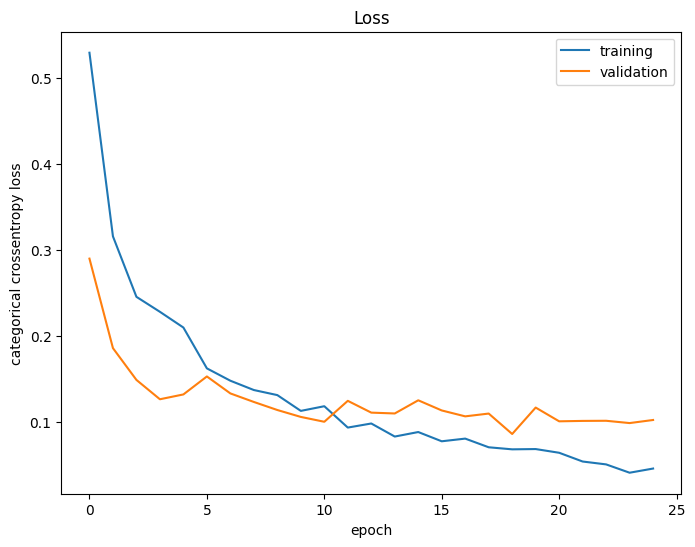

In [36]:
plot_metric_history(metric='loss',
                    val_metric='val_loss',
                    y_label='categorical crossentropy loss',
                    title='Loss')

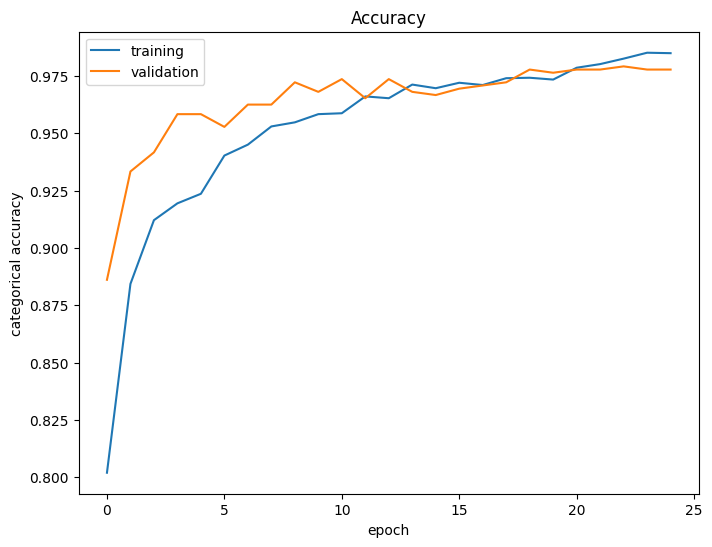

In [37]:
plot_metric_history(metric='categorical_accuracy',
                    val_metric='val_categorical_accuracy',
                    y_label='categorical accuracy',
                    title='Accuracy')

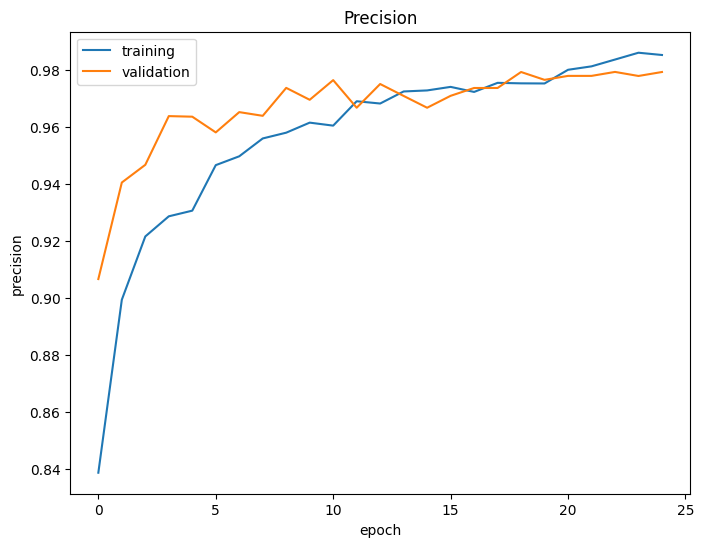

In [38]:
plot_metric_history(metric='precision',
                    val_metric='val_precision',
                    y_label='precision',
                    title='Precision')

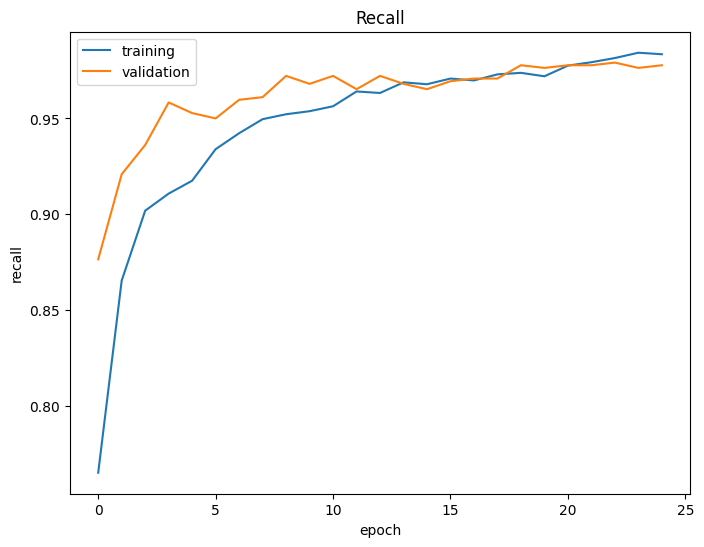

In [39]:
plot_metric_history(metric='recall',
                    val_metric='val_recall',
                    y_label='recall',
                    title='Recall')

### Evaluate the customized DenseNet121 model

In [40]:
result = model.evaluate(test_gen)
dict(zip(model.metrics_names, result))

45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - categorical_accuracy: 0.9799 - loss: 0.0702 - precision: 0.9826 - recall: 0.9792


{'loss': 0.07017462700605392, 'compile_metrics': 0.9798611402511597}

In [41]:
predictions = model.predict(test_gen)

45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step


In [42]:
y_true = test_gen.labels
y_pred = np.argmax(predictions, axis=1)

In [43]:
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       360
           1       0.96      0.97      0.97       360
           2       0.99      1.00      0.99       360
           3       0.97      0.99      0.98       360

    accuracy                           0.98      1440
   macro avg       0.98      0.98      0.98      1440
weighted avg       0.98      0.98      0.98      1440



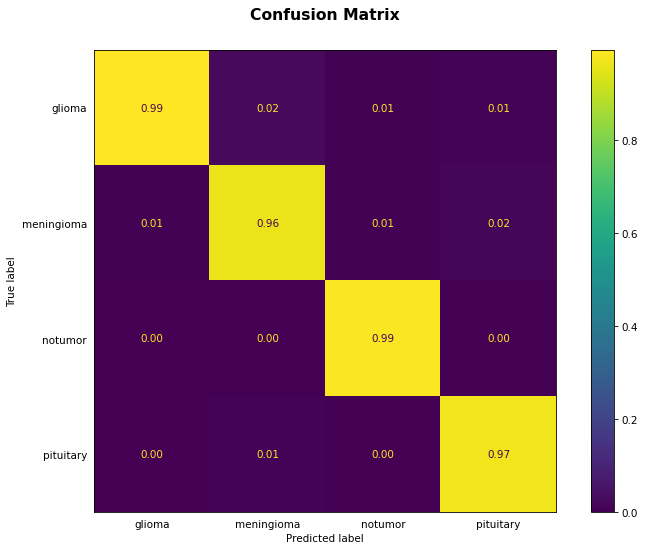

In [44]:
fig, ax = plt.subplots(facecolor='white', figsize=(12, 8), dpi=75)
fig = ConfusionMatrixDisplay.from_predictions(y_true,
                                              y_pred,
                                              display_labels=test_gen.class_indices,
                                              include_values=True,
                                              normalize='pred',
                                              values_format='.2f',
                                              cmap='viridis',
                                              ax=ax)
plt.tick_params(left=False, bottom=False)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold', pad=30)
plt.savefig('figures/confusion_matrix_cerveau.png', dpi=200)
plt.show()